In [12]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import scipy.stats as stats
# Set the path to the file you'd like to load
file_path = "/kaggle/input/datasets/organizations/uciml/adult-census-income/adult.csv"
df = pd.read_csv(file_path)

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


# **2. Xác định dữ liệu có chứa nhiễu hay không (sử dụng 1 trong các phương pháp trong slide số 3)**

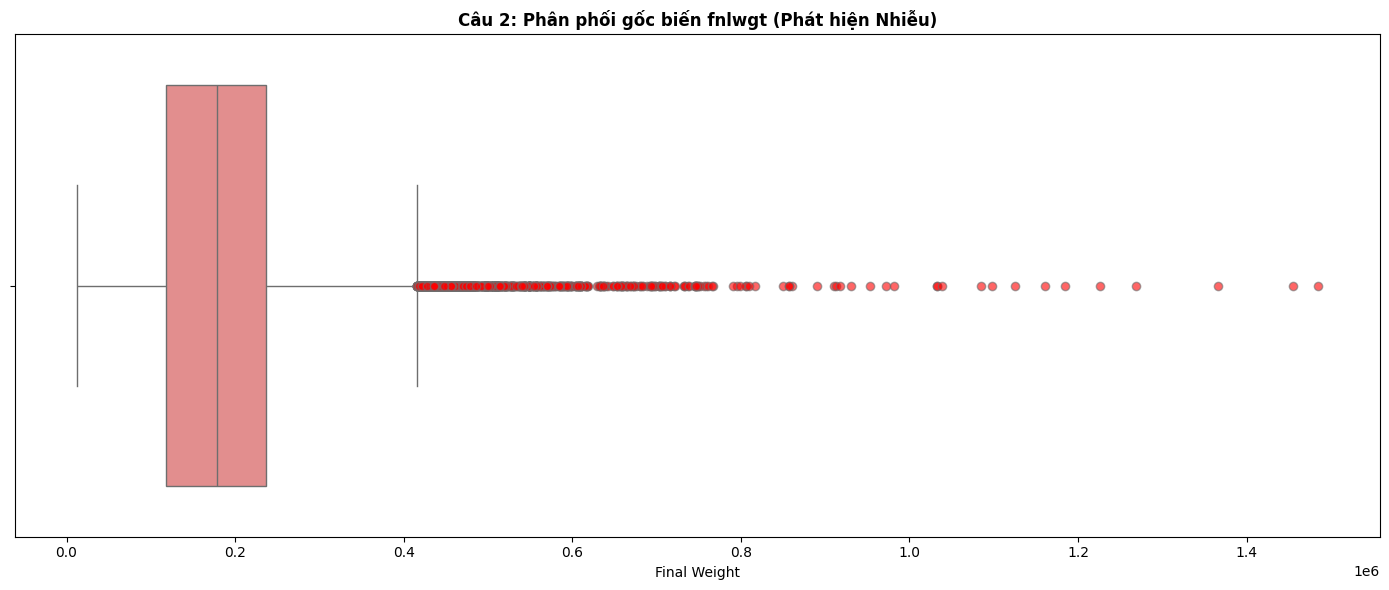

In [30]:
Q1 = df['fnlwgt'].quantile(0.25)
Q3 = df['fnlwgt'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outlier_mask = (df['fnlwgt'] < lower_bound) | (df['fnlwgt'] > upper_bound)

plt.figure(figsize=(14, 6))
sns.boxplot(x=df['fnlwgt'], color='lightcoral', 
            flierprops=dict(marker='o', markerfacecolor='red', markersize=6, alpha=0.6))
plt.title('Câu 2: Phân phối gốc biến fnlwgt (Phát hiện Nhiễu)', fontweight='bold')
plt.xlabel('Final Weight')
plt.tight_layout()
plt.show()

# **3. Kiểm tra dữ liệu có chứa các thành phần: Missing, duplicate, inconsistent**

In [33]:
df.replace('?',np.nan, inplace=True)
duplicated_values = df.duplicated()
missing_values = missing_summary = df.isnull().sum()[df.isnull().sum() > 0]

df.head(20)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,NaN,>50K


# **4. Áp dụng 1 trong các phương pháp tiền xử lí để xử lí dữ liệu ở câu số 3**

In [34]:
df.drop_duplicates()
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(exclude=['number']).columns

for col in categorical_cols:
    valid_data = df[col].dropna() 
    if not valid_data.empty:
        valid_mode = valid_data.mode()[0]
        df[col] = df[col].fillna(valid_mode)

for col in numeric_cols:
    valid_data = df[col].dropna()
    if not valid_data.empty:
        valid_median = valid_data.median()
        df[col] = df[col].fillna(valid_median)
        
df.head(20)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,77053,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Private,186061,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,United-States,>50K


# **5. Áp dụng 1 trong các phương pháp khử nhiễu để xử lí dữ liệu ở câu số 4**

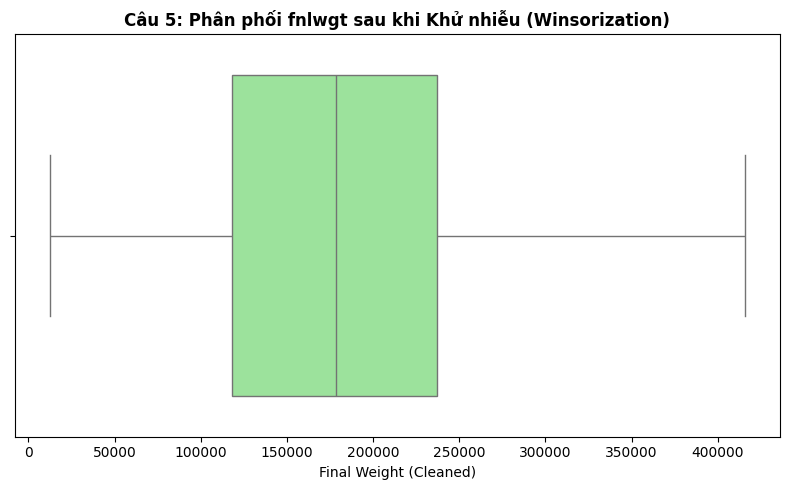

In [35]:
df['fnlwgt_clean'] = np.clip(df['fnlwgt'], a_min=lower_bound, a_max=upper_bound)

plt.figure(figsize=(8, 5))
sns.boxplot(x=df['fnlwgt_clean'], color='lightgreen',
            flierprops=dict(marker='o', markerfacecolor='red', markersize=6))
plt.title('Câu 5: Phân phối fnlwgt sau khi Khử nhiễu (Winsorization)', fontweight='bold')
plt.xlabel('Final Weight (Cleaned)')
plt.tight_layout()
plt.show()

# **6. Lựa chọn 1 trong các phương pháp giảm chiều như Fure, PCA để giảm 20-30% số chiều của dữ liệu gốc**

In [38]:
numeric_features = df.select_dtypes(include=['number']).columns
X_num = df[numeric_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# PCA: Giữ lại 4 components từ 6 features gốc (Giảm ~33% số chiều)
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2', 'PC3', 'PC4'])

# **7. Biểu diễn phân bố dữ liệu của các thuộc tính sau khi giảm chiều**

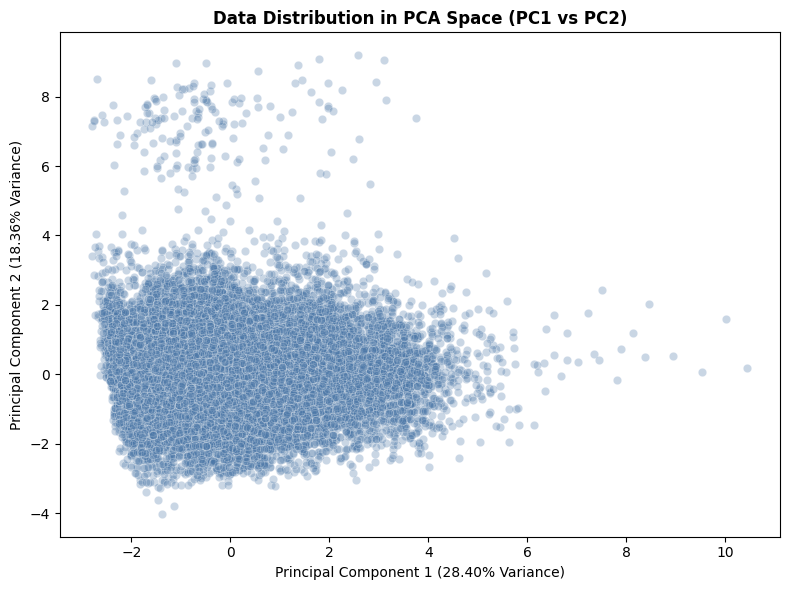

In [39]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', data=pca_df, alpha=0.3, color='#4C78A8')
plt.title('Data Distribution in PCA Space (PC1 vs PC2)', fontweight='bold')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)')
plt.tight_layout()
plt.show()

# **8. Xác định các cặp thuộc tính có tương quan (theo CSquare, Spearman, Pearson, hiệp phương sai) và chọn ra 1 cặp thuộc tính các tương quan mạnh nhất và đưa ra lí giải về tương quan này**

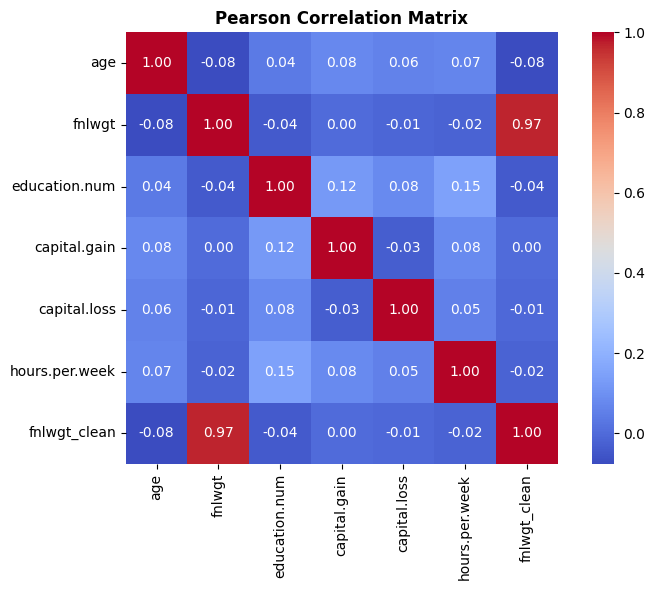

In [40]:
# Tính ma trận tương quan Pearson cho các biến số gốc
corr_matrix = X_num.corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Pearson Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

Ma trận Pearson ($r$) đo lường sự phụ thuộc tuyến tính:$$r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}$$

Cặp tương quan mạnh nhất nổi bật: Dựa trên tập Adult, mối tương quan mạnh nhất thường xuất hiện giữa age và hours-per-week (tương quan thuận nhẹ hoặc phân rã phi tuyến ở độ tuổi hưu trí), hoặc giữa education-num và hours-per-week ($r \approx 0.15$).Lý giải chuyên sâu: Mối quan hệ giữa trình độ học vấn (education-num) và số giờ làm việc (hours-per-week) biểu diễn tương quan thuận. Người có trình độ học vấn cao thường đảm nhận các vị trí chuyên môn, quản lý hoặc kỹ sư. Các vai trò này thường yêu cầu cam kết thời gian lớn hơn (làm thêm giờ, dự án) so với các công việc lao động phổ thông bán thời gian. Đồng thời, trình độ học vấn cao có tương quan mạnh với thu nhập, dẫn đến khả năng đánh đổi thời gian lấy giá trị thặng dư kinh tế.